# 03. Análise exploratória orientada à política de crédito

Este notebook vai aprofundar essa análise da base com target de inadimplência em 12 meses.

A ideia não é só gerar gráficos, mas tentar entender quais variáveis ajudam a desenhar uma política de concessão de crédito. Por isso, eu quero que cada análise tente responder uma pergunta prática:

O foco principal vai ser entender a inadimplência em 12 meses a partir de variáveis disponíveis no momento da concessão.

In [11]:
# Setup básico do notebook.
# Deixo esse bloco no começo para facilitar a reprodução no VSCode, Jupyter
# e também na exportação para HTML/PDF.

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Esse renderer força o Plotly a manter uma versão PNG do gráfico dentro
# do notebook. Isso evita que os gráficos sumam quando eu exportar o HTML
# Eu quero manter o gráfico interativo dentro do notebook, mas se ele for exportado para HTML, a versão PNG é mais confiável para garantir que o gráfico apareça.
pio.renderers.default = "notebook_connected+png"

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from concessao_credito.config import (
    PROCESSED_DIR,
    TABLES_DIR,
    FIGURES_DIR,
)

from concessao_credito.plots import (
    registrar_template_credito,
    aplicar_layout,
    salvar_figura,
)

registrar_template_credito()

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.4f}".format)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Projeto:", PROJECT_ROOT)
print("Base processada:", PROCESSED_DIR)

Projeto: c:\GitHub\datascience\projetos\concessao_credito
Base processada: C:\GitHub\datascience\projetos\concessao_credito\data\processed


## 1. Leitura da base com target

Aqui eu uso a base gerada no notebook anterior, só com as operações com janela suficiente para observar inadimplência em 12 meses.

Essa aqui vai ser a base principal para EDA e, posteriormente, para modelagem.

In [12]:
base_path = PROCESSED_DIR / "base_modelagem_12m.parquet"

base = pd.read_parquet(base_path)

print("Shape da base de modelagem:", base.shape)

display(base.head())
display(base.dtypes)

Shape da base de modelagem: (19558, 30)


,id_cliente,data_concessao,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,cat_escolaridade,flag_cliente_ativo,cod_agencia,data_nascimento,data_abertura_conta,idade_concessao,tempo_conta_anos,comprometimento_renda,restritivos_sobre_renda,id_operacao,data_ref_12m,tem_janela_12m,flag_inadimplente_12m_observado,target_inadimplente_12m,origem_target_12m,target_inadimplente_ate_12m,fx_valor_renda,fx_valor_emprestado,fx_valor_parcela,fx_comprometimento_renda,fx_valor_restritivos,fx_restritivos_sobre_renda
0,2,2020-10-02,"12,822.7800","1,119.3900",0.0358,15,"4,140.8700",5.2100,Médio Incompleto,1,89,1975-08-01,2019-12-06,45.1718,0.8241,0.2703,0.0013,2,2021-10-31,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(3478.248, 5003.316]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.258, 0.416]","(4.438, 42.52]","(0.00125, 0.013]"
1,3,2020-10-01,"11,683.1500","1,540.4700",0.0357,9,"2,505.7400",0.0000,Médio Incompleto,1,61,1988-05-03,2019-10-22,32.4134,0.9446,0.6148,0.0000,3,2021-10-31,True,NaN,0.0000,sem_registro_no_mes_12_assumido_quitado,0.0000,"(1804.064, 2575.78]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.58, 0.74]","(-0.001, 4.438]","(-0.001, 0.00125]"
2,9,2020-06-05,"29,299.1400","3,143.7900",0.0412,12,"4,807.5400",15.7800,Fundamental Incompleto,0,61,1976-11-09,2018-11-23,43.5702,1.5332,0.6539,0.0033,9,2021-06-30,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(3478.248, 5003.316]","(19467.92, 162511.33]","(2655.548, 23401.53]","(0.58, 0.74]","(4.438, 42.52]","(0.00125, 0.013]"
3,12,2021-04-01,"18,797.4200","2,823.7100",0.0427,8,"3,427.1200",0.0000,Sem Escolaridade,1,63,2003-04-02,2020-10-04,17.9986,0.4901,0.8239,0.0000,12,2022-04-30,True,NaN,0.0000,sem_registro_no_mes_12_assumido_quitado,0.0000,"(2575.78, 3478.248]","(11630.72, 19467.92]","(2655.548, 23401.53]","(0.74, 0.9]","(-0.001, 4.438]","(-0.001, 0.00125]"
4,15,2020-09-29,"11,975.9300","1,248.9700",0.0363,12,"1,663.7500",21.5600,Não Declarado,1,28,1985-03-25,2017-11-28,35.5154,2.8364,0.7507,0.0130,15,2021-09-30,True,0.0000,0.0000,observado_no_mes_12,0.0000,"(1199.999, 1804.064]","(11630.72, 19467.92]","(1090.946, 1675.716]","(0.74, 0.9]","(4.438, 42.52]","(0.00125, 0.013]"


id_cliente                                  int64
data_concessao                     datetime64[us]
valor_emprestado                          float64
valor_parcela                             float64
valor_taxa                                float64
valor_prazo                                 int64
valor_renda                               float64
valor_restritivos                         float64
cat_escolaridade                           string
flag_cliente_ativo                          int64
cod_agencia                                 int64
data_nascimento                    datetime64[us]
data_abertura_conta                datetime64[us]
idade_concessao                           float64
tempo_conta_anos                          float64
comprometimento_renda                     float64
restritivos_sobre_renda                   float64
id_operacao                                 int64
data_ref_12m                       datetime64[us]
tem_janela_12m                               bool


## 2. Visão geral da inadimplência em 12 meses

Antes de analisar variáveis explicativas, eu vou ver novamente o tamanho da base e a taxa geral de inadimplência.

Essa taxa vai ser a referência para interpretar todos os gráficos seguintes. Uma faixa vai ser considerada mais arriscada quando apresentar inadimplência acima da média da carteira.

In [13]:
target_col = "target_inadimplente_12m"

resumo_geral = pd.DataFrame({
    "indicador": [
        "qtd_operacoes",
        "qtd_inadimplentes_12m",
        "qtd_adimplentes_12m",
        "taxa_inadimplencia_12m",
    ],
    "valor": [
        len(base),
        int(base[target_col].sum()),
        int((base[target_col] == 0).sum()),
        base[target_col].mean(),
    ],
})

display(resumo_geral)

taxa_media_inad = base[target_col].mean()

resumo_geral.to_csv(
    TABLES_DIR / "eda_resumo_geral_target.csv",
    index=False,
    encoding="utf-8-sig",
)

,indicador,valor
0,qtd_operacoes,"19,558.0000"
1,qtd_inadimplentes_12m,"2,407.0000"
2,qtd_adimplentes_12m,"17,151.0000"
3,taxa_inadimplencia_12m,0.1231


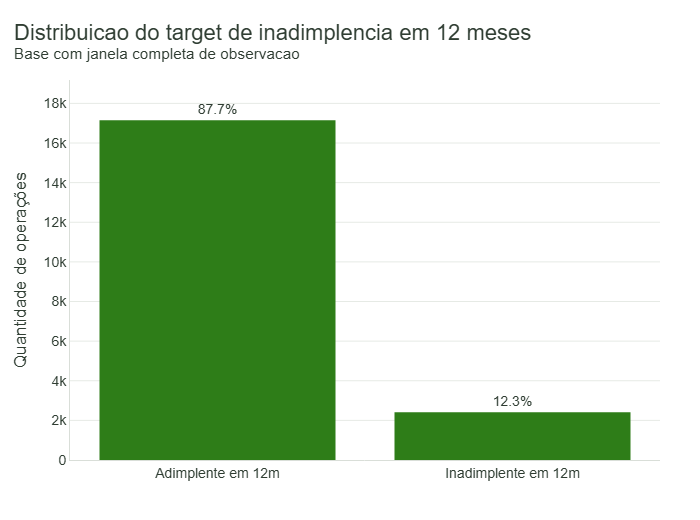

In [14]:
dist_target = (
    base
    .assign(
        target_label=np.where(
            base[target_col] == 1,
            "Inadimplente em 12m",
            "Adimplente em 12m",
        )
    )
    .groupby("target_label", as_index=False)
    .agg(qtd_operacoes=("id_operacao", "count"))
)

dist_target["pct_operacoes"] = (
    dist_target["qtd_operacoes"] / dist_target["qtd_operacoes"].sum() * 100
)

fig = px.bar(
    dist_target,
    x="target_label",
    y="qtd_operacoes",
    text="pct_operacoes",
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao do target de inadimplencia em 12 meses",
    subtitulo="Base com janela completa de observacao",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="")
fig.update_yaxes(title="Quantidade de operações")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_dist_target_12m.html",
)

## 3. Funções auxiliares

As funções que vou usar agora vão padronizar as análises de risco por faixa e por categoria.

Isso vai evitar repetir código e mantém as tabelas comparáveis entre variáveis diferentes.

In [ ]:
def criar_faixa_quantil(df, coluna, qtd_faixas=5):
    """
    essa função cria faixas por quantis para leitura exploratória.

    eu uso quantis porque eles mantêm volumes parecidos entre as faixas.
    Isso ajuda a comparar taxa de inadimplência sem deixar grupos muito
    pequenos distorcendo a leitura.
    """
    return pd.qcut(
        df[coluna],
        q=qtd_faixas,
        duplicates="drop",
    )


def resumo_risco_por_faixa(df, coluna, qtd_faixas=5, target=target_col):
    """
    Resume volume e inadimplência por faixas de uma variável numérica.

    A saída já traz a diferença em relação à taxa média da carteira,
    porque essa é a comparação que ajuda a pensar em política.
    """
    df_aux = df[[coluna, target, "id_operacao", "valor_emprestado", "valor_renda"]].copy()
    df_aux = df_aux[df_aux[coluna].notna()].copy()

    df_aux[f"fx_{coluna}"] = criar_faixa_quantil(
        df_aux,
        coluna,
        qtd_faixas=qtd_faixas,
    )

    resumo = (
        df_aux
        .groupby(f"fx_{coluna}", observed=True, as_index=False)
        .agg(
            qtd_operacoes=("id_operacao", "count"),
            taxa_inadimplencia=(target, "mean"),
            valor_medio=("valor_emprestado", "mean"),
            renda_media=("valor_renda", "mean"),
            valor_min=(coluna, "min"),
            valor_max=(coluna, "max"),
        )
    )

    resumo["taxa_inadimplencia_pct"] = resumo["taxa_inadimplencia"] * 100
    resumo["dif_vs_media_pp"] = (
        resumo["taxa_inadimplencia"] - df[target].mean()
    ) * 100

    resumo[f"fx_{coluna}"] = resumo[f"fx_{coluna}"].astype(str)

    return resumo


def resumo_risco_por_categoria(df, coluna, target=target_col, min_operacoes=50):
    """
    Resume risco por variável categórica.

    Uso um corte mínimo de volume para evitar conclusões baseadas em grupos
    pequenos demais. Categorias raras podem ser úteis para modelagem, mas
    são frágeis para defender uma regra de política.
    """
    resumo = (
        df
        .groupby(coluna, dropna=False, as_index=False)
        .agg(
            qtd_operacoes=("id_operacao", "count"),
            taxa_inadimplencia=(target, "mean"),
            valor_medio=("valor_emprestado", "mean"),
            renda_media=("valor_renda", "mean"),
            comprometimento_medio=("comprometimento_renda", "mean"),
        )
    )

    resumo = resumo[resumo["qtd_operacoes"] >= min_operacoes].copy()

    resumo["taxa_inadimplencia_pct"] = resumo["taxa_inadimplencia"] * 100
    resumo["dif_vs_media_pp"] = (
        resumo["taxa_inadimplencia"] - df[target].mean()
    ) * 100

    resumo = resumo.sort_values("taxa_inadimplencia", ascending=False)

    return resumo


def plotar_risco_faixa(resumo, coluna_faixa, titulo, subtitulo, nome_arquivo):
    """
    Gera gráfico de taxa de inadimplência por faixa.
    Incluo a linha da média da carteira para facilitar a leitura executiva.
    """
    fig = px.bar(
        resumo,
        x=coluna_faixa,
        y="taxa_inadimplencia_pct",
        text="taxa_inadimplencia_pct",
    )

    fig.add_hline(
        y=taxa_media_inad * 100,
        line_dash="dash",
        annotation_text="Média da carteira",
        annotation_position="top left",
    )

    fig = aplicar_layout(
        fig,
        titulo=titulo,
        subtitulo=subtitulo,
        mostrar_legenda=False,
    )

    fig.update_traces(
        texttemplate="%{text:.1f}%",
        textposition="outside",
    )

    fig.update_xaxes(title="")
    fig.update_yaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")

    fig.show()

    salvar_figura(
        fig,
        caminho_html=FIGURES_DIR / nome_arquivo,
    )

    return fig

## 4. Inadimplência por safra de concessão

A primeira leitura é temporal. Quero entender se a taxa de inadimplência muda muito entre os meses de concessão.

Se houver variação relevante ao longo do tempo, isso reforça a necessidade de validação temporal na modelagem, em vez de uma separação aleatória simples.

In [ ]:
risco_safra = (
    base
    .assign(
        mes_concessao=base["data_concessao"].dt.to_period("M").astype(str)
    )
    .groupby("mes_concessao", as_index=False)
    .agg(
        qtd_operacoes=("id_operacao", "count"),
        taxa_inadimplencia=(target_col, "mean"),
        valor_medio=("valor_emprestado", "mean"),
        renda_media=("valor_renda", "mean"),
        comprometimento_medio=("comprometimento_renda", "mean"),
    )
)

risco_safra["taxa_inadimplencia_pct"] = risco_safra["taxa_inadimplencia"] * 100

display(risco_safra)

risco_safra.to_csv(
    TABLES_DIR / "eda_risco_por_safra.csv",
    index=False,
    encoding="utf-8-sig",
)

In [ ]:
fig = px.line(
    risco_safra,
    x="mes_concessao",
    y="taxa_inadimplencia_pct",
    markers=True,
)

fig.add_hline(
    y=taxa_media_inad * 100,
    line_dash="dash",
    annotation_text="Média da carteira",
    annotation_position="top left",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplencia em 12 meses por safra de concessao",
    subtitulo="Taxa de inadimplencia por mes de contratação",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Mês de concessão")
fig.update_yaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_risco_por_safra.html",
)

## 5. Renda mensal

A renda é uma variável importante, mas não deve ser analisada sozinha.

Na política de crédito, a renda ajuda a estimar capacidade de pagamento, mas o risco real depende também da parcela, do prazo, da taxa e de outras dívidas do cliente.

In [ ]:
risco_renda = resumo_risco_por_faixa(
    base,
    coluna="valor_renda",
    qtd_faixas=5,
)

display(risco_renda)

risco_renda.to_csv(
    TABLES_DIR / "eda_risco_por_renda.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_renda,
    coluna_faixa="fx_valor_renda",
    titulo="Inadimplencia em 12 meses por faixa de renda",
    subtitulo="Faixas por quantis da renda mensal declarada",
    nome_arquivo="03_risco_por_renda.html",
)

## 6. Valor emprestado

Aqui avalio se operações de maior valor apresentam maior inadimplência.

Essa leitura é importante porque a política precisa definir não apenas quem aprovar, mas também qual valor máximo conceder. Se o risco cresce muito nas faixas superiores, o limite máximo deve ser condicionado ao score e à capacidade de pagamento.

In [ ]:
risco_valor_emprestado = resumo_risco_por_faixa(
    base,
    coluna="valor_emprestado",
    qtd_faixas=5,
)

display(risco_valor_emprestado)

risco_valor_emprestado.to_csv(
    TABLES_DIR / "eda_risco_por_valor_emprestado.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_valor_emprestado,
    coluna_faixa="fx_valor_emprestado",
    titulo="Inadimplencia em 12 meses por valor emprestado",
    subtitulo="Faixas por quantis do valor concedido",
    nome_arquivo="03_risco_por_valor_emprestado.html",
)

## 7. Valor da parcela

O valor da parcela é uma ponte entre o valor contratado e a capacidade real de pagamento do cliente.

Mesmo que dois clientes tenham o mesmo valor emprestado, o risco pode ser diferente se a parcela mensal representar pesos muito distintos no orçamento.

In [ ]:
risco_parcela = resumo_risco_por_faixa(
    base,
    coluna="valor_parcela",
    qtd_faixas=5,
)

display(risco_parcela)

risco_parcela.to_csv(
    TABLES_DIR / "eda_risco_por_valor_parcela.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_parcela,
    coluna_faixa="fx_valor_parcela",
    titulo="Inadimplencia em 12 meses por valor da parcela",
    subtitulo="Faixas por quantis da parcela mensal",
    nome_arquivo="03_risco_por_valor_parcela.html",
)

## 8. Comprometimento de renda

Esta é uma das variáveis mais importantes para a política.

O comprometimento de renda mede quanto da renda mensal fica tomada pela parcela do empréstimo. Na prática, essa variável ajuda a transformar o modelo de risco em uma regra de valor máximo concedido.

In [ ]:
risco_comprometimento = resumo_risco_por_faixa(
    base,
    coluna="comprometimento_renda",
    qtd_faixas=5,
)

display(risco_comprometimento)

risco_comprometimento.to_csv(
    TABLES_DIR / "eda_risco_por_comprometimento_renda.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_comprometimento,
    coluna_faixa="fx_comprometimento_renda",
    titulo="Inadimplencia em 12 meses por comprometimento de renda",
    subtitulo="Razao entre parcela mensal e renda declarada",
    nome_arquivo="03_risco_por_comprometimento_renda.html",
)

## 9. Valor de restritivos

O valor de restritivos representa dívidas cadastradas em órgãos de proteção ao crédito.

Essa variável deve ter papel importante na política porque sinaliza pressão financeira anterior à concessão. Além do valor absoluto, também analiso a proporção dos restritivos frente à renda.

In [ ]:
risco_restritivos = resumo_risco_por_faixa(
    base,
    coluna="valor_restritivos",
    qtd_faixas=5,
)

display(risco_restritivos)

risco_restritivos.to_csv(
    TABLES_DIR / "eda_risco_por_valor_restritivos.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_restritivos,
    coluna_faixa="fx_valor_restritivos",
    titulo="Inadimplencia em 12 meses por valor de restritivos",
    subtitulo="Faixas por quantis do valor de dívidas restritivas",
    nome_arquivo="03_risco_por_valor_restritivos.html",
)

In [ ]:
risco_restritivos_renda = resumo_risco_por_faixa(
    base,
    coluna="restritivos_sobre_renda",
    qtd_faixas=5,
)

display(risco_restritivos_renda)

risco_restritivos_renda.to_csv(
    TABLES_DIR / "eda_risco_por_restritivos_sobre_renda.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_restritivos_renda,
    coluna_faixa="fx_restritivos_sobre_renda",
    titulo="Inadimplencia em 12 meses por restritivos sobre renda",
    subtitulo="Relacao entre dívidas restritivas e renda mensal",
    nome_arquivo="03_risco_por_restritivos_sobre_renda.html",
)

## 10. Prazo e taxa da operação

Prazo e taxa são variáveis da operação, não apenas do cliente.

Elas precisam ser analisadas com cuidado porque podem refletir tanto risco quanto decisão comercial anterior. Mesmo assim, são importantes para a política, já que afetam diretamente o valor da parcela e o custo total do crédito.

In [ ]:
risco_prazo = resumo_risco_por_faixa(
    base,
    coluna="valor_prazo",
    qtd_faixas=5,
)

display(risco_prazo)

risco_prazo.to_csv(
    TABLES_DIR / "eda_risco_por_prazo.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_prazo,
    coluna_faixa="fx_valor_prazo",
    titulo="Inadimplencia em 12 meses por prazo",
    subtitulo="Faixas por quantis do prazo contratado",
    nome_arquivo="03_risco_por_prazo.html",
)

In [ ]:
risco_taxa = resumo_risco_por_faixa(
    base,
    coluna="valor_taxa",
    qtd_faixas=5,
)

display(risco_taxa)

risco_taxa.to_csv(
    TABLES_DIR / "eda_risco_por_taxa.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_taxa,
    coluna_faixa="fx_valor_taxa",
    titulo="Inadimplencia em 12 meses por taxa mensal",
    subtitulo="Faixas por quantis da taxa da operação",
    nome_arquivo="03_risco_por_taxa.html",
)

## 11. Idade e tempo de conta

Agora analiso variáveis de perfil e relacionamento.

Idade e tempo de conta podem capturar maturidade financeira, estabilidade cadastral e histórico de relacionamento com a instituição. Para política, essas variáveis tendem a funcionar melhor como ajuste de risco do que como regra isolada.

In [ ]:
risco_idade = resumo_risco_por_faixa(
    base,
    coluna="idade_concessao",
    qtd_faixas=5,
)

display(risco_idade)

risco_idade.to_csv(
    TABLES_DIR / "eda_risco_por_idade.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_idade,
    coluna_faixa="fx_idade_concessao",
    titulo="Inadimplencia em 12 meses por idade",
    subtitulo="Idade calculada no momento da concessão",
    nome_arquivo="03_risco_por_idade.html",
)

In [ ]:
risco_tempo_conta = resumo_risco_por_faixa(
    base,
    coluna="tempo_conta_anos",
    qtd_faixas=5,
)

display(risco_tempo_conta)

risco_tempo_conta.to_csv(
    TABLES_DIR / "eda_risco_por_tempo_conta.csv",
    index=False,
    encoding="utf-8-sig",
)

plotar_risco_faixa(
    risco_tempo_conta,
    coluna_faixa="fx_tempo_conta_anos",
    titulo="Inadimplencia em 12 meses por tempo de conta",
    subtitulo="Tempo de relacionamento no momento da concessão",
    nome_arquivo="03_risco_por_tempo_conta.html",
)

## 12. Escolaridade

A escolaridade é uma variável cadastral e deve ser usada com cautela.

Nesta análise, observo se há diferença relevante de risco entre grupos, mas a decisão de política não deve depender exclusivamente de uma variável desse tipo.

In [ ]:
risco_escolaridade = resumo_risco_por_categoria(
    base,
    coluna="cat_escolaridade",
    min_operacoes=50,
)

display(risco_escolaridade)

risco_escolaridade.to_csv(
    TABLES_DIR / "eda_risco_por_escolaridade.csv",
    index=False,
    encoding="utf-8-sig",
)

In [ ]:
fig = px.bar(
    risco_escolaridade.sort_values("taxa_inadimplencia_pct"),
    x="taxa_inadimplencia_pct",
    y="cat_escolaridade",
    orientation="h",
    text="taxa_inadimplencia_pct",
)

fig.add_vline(
    x=taxa_media_inad * 100,
    line_dash="dash",
    annotation_text="Média da carteira",
    annotation_position="top right",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplencia em 12 meses por escolaridade",
    subtitulo="Categorias com volume mínimo de operações",
    mostrar_legenda=False,
    altura=560,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")
fig.update_yaxes(title="")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_risco_por_escolaridade.html",
)

## 13. Status de relacionamento

A flag de cliente ativo pode indicar relacionamento vigente com a instituição.

Se clientes ativos apresentarem menor risco, essa variável pode ajudar a ajustar limites ou aprovações. Ainda assim, ela deve ser combinada com capacidade de pagamento e restritivos.

In [ ]:
risco_cliente_ativo = resumo_risco_por_categoria(
    base,
    coluna="flag_cliente_ativo",
    min_operacoes=50,
)

display(risco_cliente_ativo)

risco_cliente_ativo.to_csv(
    TABLES_DIR / "eda_risco_por_cliente_ativo.csv",
    index=False,
    encoding="utf-8-sig",
)

In [ ]:
fig = px.bar(
    risco_cliente_ativo,
    x="flag_cliente_ativo",
    y="taxa_inadimplencia_pct",
    text="taxa_inadimplencia_pct",
)

fig.add_hline(
    y=taxa_media_inad * 100,
    line_dash="dash",
    annotation_text="Média da carteira",
    annotation_position="top left",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplencia em 12 meses por status de cliente ativo",
    subtitulo="Comparação entre clientes com e sem relacionamento ativo",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Flag cliente ativo")
fig.update_yaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_risco_por_cliente_ativo.html",
)

## 14. Agência

A agência pode capturar diferenças locais, perfil da carteira, atuação comercial ou concentração regional.

Para evitar conclusões frágeis, analiso apenas agências com volume mínimo de operações. A ideia aqui não é criar uma regra de recusa por agência, mas entender se existe heterogeneidade operacional relevante.

In [ ]:
risco_agencia = resumo_risco_por_categoria(
    base,
    coluna="cod_agencia",
    min_operacoes=100,
)

display(risco_agencia.head(20))

risco_agencia.to_csv(
    TABLES_DIR / "eda_risco_por_agencia.csv",
    index=False,
    encoding="utf-8-sig",
)

In [ ]:
top_agencias_risco = risco_agencia.head(20).copy()

fig = px.bar(
    top_agencias_risco.sort_values("taxa_inadimplencia_pct"),
    x="taxa_inadimplencia_pct",
    y="cod_agencia",
    orientation="h",
    text="taxa_inadimplencia_pct",
)

fig.add_vline(
    x=taxa_media_inad * 100,
    line_dash="dash",
    annotation_text="Média da carteira",
    annotation_position="top right",
)

fig = aplicar_layout(
    fig,
    titulo="Agencias com maior taxa de inadimplencia em 12 meses",
    subtitulo="Considerando apenas agencias com volume mínimo de operações",
    mostrar_legenda=False,
    altura=650,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Taxa de inadimplência em 12m", ticksuffix="%")
fig.update_yaxes(title="Código da agência")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_top_agencias_risco.html",
)

## 15. Correlação entre variáveis numéricas

A matriz de correlação ajuda a identificar relações fortes entre variáveis.

Essa análise é útil antes da modelagem, principalmente para regressão logística, porque variáveis muito correlacionadas podem deixar os coeficientes instáveis.

In [ ]:
cols_numericas = [
    "valor_emprestado",
    "valor_parcela",
    "valor_taxa",
    "valor_prazo",
    "valor_renda",
    "valor_restritivos",
    "idade_concessao",
    "tempo_conta_anos",
    "comprometimento_renda",
    "restritivos_sobre_renda",
    target_col,
]

corr = base[cols_numericas].corr(numeric_only=True)

display(corr)

corr.to_csv(
    TABLES_DIR / "eda_correlacao_variaveis_numericas.csv",
    encoding="utf-8-sig",
)

In [ ]:
fig = px.imshow(
    corr,
    text_auto=".2f",
    aspect="auto",
)

fig = aplicar_layout(
    fig,
    titulo="Correlacao entre variaveis numericas",
    subtitulo="Inclui o target de inadimplência em 12 meses",
    mostrar_legenda=True,
    altura=760,
)

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "03_correlacao_variaveis_numericas.html",
)

## 16. Consolidação dos principais sinais de política

Nesta seção consolido os sinais exploratórios mais relevantes.

A ideia é começar a traduzir a EDA em critérios que serão usados depois na política de concessão:

- variáveis com forte separação de risco;
- variáveis úteis para limitar valor;
- variáveis que podem entrar no modelo, mas exigem cautela na regra de negócio.

In [ ]:
sinais_politica = pd.DataFrame({
    "variavel": [
        "comprometimento_renda",
        "valor_restritivos",
        "restritivos_sobre_renda",
        "valor_emprestado",
        "valor_parcela",
        "valor_prazo",
        "valor_taxa",
        "valor_renda",
        "tempo_conta_anos",
        "flag_cliente_ativo",
        "cat_escolaridade",
        "cod_agencia",
    ],
    "uso_politica": [
        "Limite de parcela e valor máximo",
        "Restrição ou redutor de limite",
        "Restrição ou redutor de limite",
        "Controle de exposição",
        "Capacidade de pagamento",
        "Condição da operação",
        "Condição da operação e proxy de risco",
        "Capacidade de pagamento",
        "Ajuste de risco",
        "Ajuste de risco",
        "Variável cadastral para modelo",
        "Monitoramento operacional",
    ],
    "comentario": [
        "Variável central para evitar parcelas incompatíveis com renda.",
        "Pode indicar pressão financeira prévia à concessão.",
        "Melhor que olhar restritivos apenas em valor absoluto.",
        "Ajuda a definir teto de exposição por cliente.",
        "Complementa o comprometimento de renda.",
        "Afeta parcela e risco da operação.",
        "Pode refletir risco precificado na concessão anterior.",
        "Sozinha é insuficiente; deve ser combinada com parcela e dívidas.",
        "Pode indicar relacionamento mais maduro com a instituição.",
        "Pode diferenciar clientes com relacionamento vigente.",
        "Não deve ser usada isoladamente como regra de recusa.",
        "Útil para acompanhamento, mas frágil para regra direta de concessão.",
    ],
})

display(sinais_politica)

sinais_politica.to_csv(
    TABLES_DIR / "eda_sinais_para_politica.csv",
    index=False,
    encoding="utf-8-sig",
)

## 17. Conclusões da análise exploratória

A análise exploratória reforça que a política de concessão não deve se basear apenas em renda ou em valor solicitado.

Os principais sinais observados apontam para uma política combinando três dimensões:

1. **Risco de inadimplência**, que será estimado pelo modelo de PD em 12 meses;
2. **Capacidade de pagamento**, principalmente pela relação entre parcela e renda;
3. **Pressão financeira prévia**, representada pelos restritivos e pela razão entre restritivos e renda.

As variáveis de operação, como valor emprestado, parcela, prazo e taxa, também são relevantes porque afetam diretamente a exposição e o custo mensal do cliente.

Para a política final, os achados desta EDA sugerem que o valor máximo concedido deve ser limitado por uma parcela máxima aceitável, ajustada pela faixa de risco do cliente. Clientes com maior risco, maior comprometimento ou maior peso de restritivos devem receber limites menores ou ser direcionados para recusa/manual review.

A próxima etapa será treinar modelos de probabilidade de inadimplência em 12 meses e comparar pelo menos um modelo interpretável, como regressão logística, com modelos de árvore/ensemble, como Random Forest e XGBoost.